<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E9%9D%9E%E7%BA%BF%E6%80%A7%E6%BF%80%E6%B4%BB%E5%B1%82/Non_linearActivations%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#非线性激活
---
###Question1:为什么神经网络要非线性？
我们先看一个两层的神经网络：
$$h=W_1x+b_1,$$$$y=W_2x+b_2.$$
代入整理得到：$$y=(W_1W_2)x+(W_2b_1+b_2)$$
以此类推，如果每一层都是线性的，那么无论多少层最后一定也是线性的。我们使用的卷积本质上也是一个线性变换，所以如果没有非线性层，那么数学表达上还是等价于一个线性计算。加入非线性激活函数后，神经网络就可以表达：
*   曲线
*   分段函数
*   非线性边缘
*   高阶特征组合
*   极其复杂的输入输出映射

神经网络的基本结构可以理解为：线性变换+非线性变换+线性变换+非线性变换……
###Question2:激活函数实际上在做什么？
以某个神经元为例，线性层先得到：
$$z=w^Tx+b$$
激活函数进行：
$$a=f(z)$$
可以理解成：
线性层负责“计算某种特征响应”，激活函数决定“这个响应应该以什么方式继续向后传播，即进行特征选择”。
###Question3:怎样评价一个激活函数？
| 特性 | 意义 |
|---|---|
| 非线性 | 能否增加网络表达能力  |
| 梯度大小 | 是否容易发生梯度消失 |
| 是否饱和 | 大输入时梯度是否趋近 0 |
| 负半轴 | 是否允许负值传播 |
| 是否零中心 | 输出是否同时具有正负值 |
| 平滑性 | 是否处处可导 |
| 单调性 | 输入增大时输出是否一定增大 |
| 稀疏性 | 是否会产生大量 0 |
| 计算量 | sigmoid / exp / erf 通常比 ReLU 贵 |
| 是否有参数 | 如 PReLU 有可学习参数 |
| 数值稳定性 | 深层网络中是否稳定 |

现代激活函数的演进，大体就是在寻找：表达能力+梯度传播+计算成本之间更好的平衡。








In [50]:
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, Markdown, Math


x = torch.linspace(-6, 6, 1000)


def activation_card(
    name,
    activation,
    formula,
    description,
    xlim=(-6, 6),
    ylim=None
):
    # =========================
    # 左侧：文字 + 数学公式
    # =========================
    left_output = widgets.Output(
        layout=widgets.Layout(
            width="48%",
            padding="15px"
        )
    )

    with left_output:

        # 标题
        display(Markdown(f"## {name}"))

        # 小标题
        display(Markdown("**数学定义：**"))

        # 关键：直接用 IPython Math 渲染 LaTeX
        display(Math(formula))

        # 说明文字
        display(Markdown(description))


    # =========================
    # 右侧：函数图像
    # =========================
    right_output = widgets.Output(
        layout=widgets.Layout(
            width="52%"
        )
    )

    with right_output:

        with torch.no_grad():
            y = activation(x)

        fig, ax = plt.subplots(figsize=(5, 3.5))

        ax.plot(x.numpy(), y.numpy())

        ax.axhline(0, linewidth=0.8)
        ax.axvline(0, linewidth=0.8)

        ax.grid(alpha=0.25)

        ax.set_xlim(*xlim)

        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.set_title(name)

        plt.show()


    # =========================
    # 左右并排
    # =========================
    display(
        widgets.HBox(
            [left_output, right_output],
            layout=widgets.Layout(
                width="100%",
                align_items="center"
            )
        )
    )
def compare_activations(names):

    x = torch.linspace(-6, 6, 1200)

    activations = {
        "ReLU": nn.ReLU(),
        "LeakyReLU": nn.LeakyReLU(0.1),
        "ELU": nn.ELU(),
        "GELU": nn.GELU(),
        "SiLU": nn.SiLU(),
        "Mish": nn.Mish(),
        "Sigmoid": nn.Sigmoid(),
        "Tanh": nn.Tanh(),
        "Softplus": nn.Softplus(),
    }

    fig = go.Figure()

    for name in names:

        with torch.no_grad():
            y = activations[name](x)

        fig.add_trace(
            go.Scatter(
                x=x.numpy(),
                y=y.numpy(),
                mode="lines",
                name=name
            )
        )

    fig.update_layout(
        title="Activation Comparison",
        xaxis_title="x",
        yaxis_title="f(x)",
        width=850,
        height=500,
        hovermode="x unified"
    )

    fig.show()

##最重要的激活函数：ReLU


```
class torch.nn.ReLU(inplace=False)
#inplace=True (原地操作)：表示激活函数会直接在输入的Tensor 上进行修改。也就是说，原本的输入数据会被覆盖，不再保留计算前的值，用于节省显存。
#inplace=False (默认值)：表示激活函数会创建一个新的 Tensor 来存储输出结果，原始的输入 Tensor *保持不变。一般设置为False*
```




In [71]:
# @title
activation_card(
    name="ReLU",
    activation=nn.ReLU(),
    formula=r"""ReLU(x)=max(0,x)""",
    description="""
    特点：
    - 正半轴保持线性；
    - 负半轴直接置零；
    - 计算及其简单；
    - 将负值归零，天然容易产生稀疏激活；
    - 可能出现 Dead ReLU（神经元死亡）：
    - 假设某个神经元长期$x<0$,那么$f(x)=f'(x)=0$，这个神经元可能永远更新不过来了。
    """,
    ylim=(-1, 6)
)

##LeakyReLU：解决ReLU负区间梯度为0

```
class torch.nn.LeakyReLU(negative_slope=0.01, inplace=False)
```



In [68]:
activation_card(
    name="LeakyReLU",
    activation=nn.LeakyReLU(negative_slope=0.03, inplace=False),
    formula=r"""PReLU(x)=max(0,x)+negative_{slope}∗min(0,x)=\begin{cases}
    x,&x\geq0\\
    ax,&x<0
    \end{cases}""",
    description="""
    - 和ReLU的区别就在负半轴
    - LeakyReLU的负半轴梯度为很小的正数，所以神经元即使进入负区间，仍然能够得到梯度。
    - 负数没有完全关闭，只是大幅度削弱了,可以避免Dead ReLU.
    """,
    ylim=(-0.5, 6)
)

##PReLU：让负斜率自己学
LeakyReLU的负半轴斜率要自己设置，没有理论答案，因此有了可训练负半轴斜率的PReLU。


```
class torch.nn.PReLU(num_parameters=1, init=0.25, device=None, dtype=None)
#num_parameters:控制学习参数negative_slope的数量，只有两个合法值:1和输入通道数，表示所有通道共用一个negative_slope和每个通道分开训练一个negative_slope。默认为1
#init:negative_slope的初始值，默认为0.25，表示模型刚开始训练时负半轴的默认斜率，在此基础上通过反向传播自动调整。
#device & dtype：指定参数存储的设备以及数据类型，比如cuda;torch.float32。
```



In [67]:
activation_card(
    name="PReLU",
    activation=nn.PReLU(num_parameters=1, init=0.25, device=None, dtype=None),
    formula=r"""PReLU(x)=max(0,x)+negative_{slope}∗min(0,x)=\begin{cases}
    x,&x\geq0\\
    ax,&x<0
    \end{cases}""",
    description="""
    - $a(negative_{slope})$是可训练参数，网络自己决定该保留多少负值：<br>
    - PReLU是少数包含可训练参数的激活函数
    """,
    ylim=(-2, 6)
)

##RReLU：随机版本 LeakyReLU
核心特点：在训练过程中，负半轴的斜率是从一个均匀分布中随机采样得到的。训练模式下每一轮迭代都不同，起到正则化的作用，减少过拟合。测试模式下负半轴斜率固定为上下界的平均值，默认为0.0092


```
class torch.nn.RReLU(lower=0.125, upper=0.3333333333333333, inplace=False)
#lower:均匀分布的下界，默认值0.125
#upper:均匀分布的上界，默认值0.333333

```



In [121]:
activation_card(
    name="RReLU",
    activation=nn.RReLU(lower=0.125, upper=0.3333333333333333, inplace=False),

    formula=r"""RReLU(x)=
    \begin{cases}
    x,&x\geq0\\
    ax,&x<0
    \end{cases}""",

    description="""
    - $ a(negative_{slope})$ 是随机参数
    - 可以看到每个函数点采用每次随机得到的斜率，点分布在上下界之间。
    - 给激活增加随机扰动，形成一定正则化效果,增加网络的泛化能力。
    - 目前比较少用。
    """,
    ylim=(-2.5, 6)
)

##Sigmoid：最经典，但已经很少用于隐藏层

```
class torch.nn.Sigmoid()
#没有参数，不支持原地操作
```
比较适合表达：概率、开关、门控程度。核心问题在于梯度消失，梯度最大点也仅有0.25，其余点或者多次Sigmoid时梯度迅速降到接近0。现代深层网络很少使用 Sigmoid 作为普通 hidden activation，但是在门控或二分类时依旧很重要。




In [72]:
activation_card(
    name="Sigmoid",

    activation=torch.nn.Sigmoid(),

    formula=r"""\sigma(x)=\frac{1}{1+e^{-x}}""",

    description=r"""
### 特点

- 输出范围为 $(0,1)$
- 可以表示概率或者门控程度
- 当 $|x|$ 较大时容易进入饱和区
- 深层网络中容易出现梯度消失
""",

    ylim=(-0.2, 1.2)
)

##Tanh：零中心版 Sigmoid
```
class torch.nn.Tanh()
```
导数最大值为1，比Sigmoid好得多，但是深层网络依然存在梯度消失问题

In [120]:
activation_card(
    name="Tanh",

    activation=torch.nn.Tanh(),

    formula=r"""Tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}""",

    description=r"""
### 特点

- 输出范围为 $(-1,1)$
- 常出现于RNN、LSTM、输出限制在$[-1,1]$的模型
- 当 $|x|$ 较大时进入饱和区
- 深层网络中依然容易出现梯度消失
""",

    ylim=(-1.2, 1.2)
)

##GELU：Transformer 时代非常重要

```
class torch.nn.GELU(approximate='none')
#approximate：指定是否使用近似算法来计算GELU，因为GELU的原始定义设计高斯误差函数，计算量较大。默认使用精确公式计算，“tanh”使用基于tanh函数的近似公式，计算更快且误差很小
```
全称Gaussian Error Linear Unit。
相比于ReLU更平滑，在负半轴不完全为0，保留了一点负反馈。

GELU可以理解为$$f(x)=x×"保留概率"$$
$x$很负时$\Phi(x)≈0$,基本删除；$x$很正时$\Phi(x)≈1$,基本保留；在0附近平滑地决定保留多少，小负值不会完全删除，保留了一小部分负值信息。

In [93]:
activation_card(
    name="GELU",

    activation=torch.nn.GELU(),

    formula=r"""GELU(x)=x{\Phi(x)}
\approx
\frac12x
\left[
1+
\tanh
\left(
\sqrt{\frac2\pi}
(x+0.044715x^3)
\right)
\right]""",

    description=r"""
### 特点

- 相当于更平滑、非严格单调、更可以概率解释的ReLU
- 在Transformer领域很常见
- 可以把它视为现代神经网络中最核心的激活函数之一
""",

    ylim=(-1, 6)
)

##SiLU（也叫Swish）：现在同样非常重要


```
class torch.nn.SiLU(inplace=False)
```
和 GELU 的思想非常相似，都相当于$$x×一个平滑门$$


In [96]:
activation_card(
    name="SiLU",

    activation=torch.nn.SiLU(),

    formula=r"""
SiLU(x)=x\sigma(x)=
\frac{x}{1+e^{-x}}
""",

    description=r"""
### 特点

- 思想和GELU类似
- 常见于CNN、YOLO等视觉网络、一些Transformer/LLM架构
- GELU和SiLU是现代模型里非常值得掌握的两个激活函数
""",

    ylim=(-1, 6)
)

##Mish

```
class torch.nn.Mish(inplace=False)
```
同样是平滑、保留少量负值、正区间近似线性的激活函数。


In [100]:
activation_card(
    name="Mish",

    activation=torch.nn.Mish(),

    formula=r"""Mish(x)=
x\tanh(\ln(1+e^x))=x\tanh(softplus(x))
""",

    description=r"""
### 特点

- 形状和 SiLU 非常相似
- 优点是梯度比较平滑
- 缺点是计算更加复杂
""",

    ylim=(-1, 6)
)

##Softplus：ReLU 的真正“平滑版本”


```
class torch.nn.Softplus(beta=1.0, threshold=20.0)
```
相当于拐角很圆滑的ReLU。
它的导数：

$$\frac{d}{dx}Softplus(x)
=
\frac{1}{1+e^{-x}}
=
\sigma(x)$$
即：
$$\boxed{Softplus'(x)=Sigmoid(x)}$$
Softplus 经常用于要求输出>0的地方，比如预测方差、标准差、尺度参数等。相比于ReLU,Softplus更平滑，而且不会大面积得到精确的0。

In [105]:
activation_card(
    name="Softplus",

    activation=torch.nn.Softplus(beta=1.0, threshold=20.0),

    formula=r"""Softplus(x)=\ln(1+e^x)""",

    description=r"""
### 特点

- 平滑版本的ReLU
- 常用于要求输出>0的地方

""",

    ylim=(-1, 6)
)

##ELU（Exponential Linear Unit）

ELU 同样为了解决 ReLU 在负半轴梯度完全为 0 的问题。

```
class torch.nn.ELU(alpha=1.0, inplace=False)
#alpha：决定负值下界，默认为1。
```
其定义为：

$$
f(x)=
\begin{cases}
x, & x>0\\
\alpha(e^x-1), & x\leq 0
\end{cases}
$$

其中 $\alpha>0$ 是超参数，通常取 $\alpha=1$。



$$
x\rightarrow-\infty
$$

有：

$$
f(x)\rightarrow-\alpha
$$

也就是说 ELU 的负半轴最终会进入一个负饱和区域。

ELU 可以理解为：正半轴保持 ReLU 的简单线性性质，负半轴则使用平滑、有限的负响应代替直接截断。

缺点：ELU需要进行指数运算，因此计算成本高于 ReLU 和 LeakyReLU。

In [118]:
activation_card(
    name="ELU",
    activation=nn.ELU(alpha=1.0),
    formula=r"""
ELU(x)=
\begin{cases}
x, & x>0 \\
e^x-1, & x\leq0
\end{cases}
""",
    description=r"""
### 核心特点

- 正半轴与 ReLU 相同，完全线性
- 负半轴平滑且允许负输出
- 可以缓解 Dead ReLU
- 当 $x\to-\infty$ 时趋近于 $-1$
- 需要指数运算，计算成本偏高
""",
    ylim=(-1.5, 6)
)

##CELU--对ELU的数学修正


```
class torch.nn.CELU(alpha=1.0, inplace=False)
```


CELU 是 ELU 的一个变体：
$$
f(x)=
\begin{cases}
x, & x\geq0\\
\alpha\left(e^{x/\alpha}-1\right), & x<0
\end{cases}
$$

CELU 可以理解为数学性质更加规整的 ELU。它的主要目的，是使不同 $\alpha$ 下函数在 $x=0$ 附近保持可微性质。

In [117]:
activation_card(
    name="CELU",
    activation=nn.CELU(alpha=1.0),
    formula=r"""
CELU(x)=
\begin{cases}
x, & x\geq0\\
\alpha(e^{x/\alpha}-1), & x<0
\end{cases}
""",
    description=r"""
CELU 是 ELU 的连续可微改进版本。

""",
    ylim=(-1.5, 6)
)

##SELU（Scaled Exponential Linear Unit）


```
class torch.nn.SELU(inplace=False)
```



SELU 是 ELU 的缩放版本，其设计目标并不仅仅是改善激活函数本身，而是实现：

$$
\text{Self-Normalizing Neural Network}
$$

即**自归一化神经网络**。

其形式为：

$$
f(x)=
\lambda
\begin{cases}
x, & x>0\\
\alpha(e^x-1), & x\leq0
\end{cases}
$$

其中通常固定：

$$
\alpha\approx1.6733
$$

$$
\lambda\approx1.0507
$$

这些数值并不是随意选择，而是通过理论分析得到的。

---

### 核心目标：保持激活分布稳定

在深层网络中，希望每层神经元的输出大致保持：

$$
E[x]\approx0
$$

以及：

$$
Var(x)\approx1
$$

SELU 的设计使得在满足一定条件时，网络中的激活均值和方差会倾向于回到一个稳定区域。

因此有：

$$
(\mu,\sigma^2)
\rightarrow
(0,1)
$$

的趋势。

---

### SELU 与普通 ELU 的区别

ELU 主要解决：

- ReLU 负半轴完全为 0；
- 输出均值偏正；
- Dead ReLU。

SELU 则进一步希望：整个深层网络的激活分布能够自动保持稳定。

因此 SELU 是一个和网络初始化、结构、Dropout 方法共同设计的激活函数。

SELU 通常需要配合：

- LeCun Normal 初始化；
- 合适的全连接网络结构；
- AlphaDropout，而不是普通 Dropout。

因此它不像 ReLU、GELU、SiLU 那样可以随意替换。

In [116]:
activation_card(
    name="SELU",
    activation=nn.SELU(),
    formula=r"""
SELU(x)=
\lambda
\begin{cases}
x, & x>0\\
\alpha(e^x-1), & x\leq0
\end{cases}
""",
    description=r"""
特点

SELU 是为了 **Self-Normalizing Neural Network** 专门设计的。

在满足特定初始化和网络结构条件时，希望激活分布保持：

$$
E[x]\approx0,\qquad Var(x)\approx1
$$

它通常需要配合 LeCun Normal 初始化以及 AlphaDropout，因此并不是可以随意替换 ReLU 的通用激活函数。
""",
    ylim=(-2, 6)
)

##HardSigmoid
普通 Sigmoid 为：

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

其中包含指数运算。

HardSigmoid 使用简单的分段线性函数进行近似：

$$
f(x)=
\begin{cases}
0, & x\leq-3\\
\dfrac{x}{6}+\dfrac12, & -3<x<3\\
1, & x\geq3
\end{cases}
$$

它牺牲了一部分平滑性，以换取更低的计算成本。

In [115]:
activation_card(
    name="HardSigmoid",
    activation=nn.Hardsigmoid(),
    formula=r"""
HardSigmoid(x)=
\begin{cases}
0, & x\leq-3\\
x/6+1/2, & -3<x<3\\
1, & x\geq3
\end{cases}
""",
    description=r"""
Sigmoid 的廉价分段线性近似。

主要用于对计算效率要求较高的轻量网络。
""",
    ylim=(-0.2, 1.2)
)

## HardSwish


```
class torch.nn.Hardswish(inplace=False)
```

SiLU / Swish 的定义为：

$$
\operatorname{SiLU}(x)=x\sigma(x)
$$

HardSwish 将其中的 Sigmoid 替换为 HardSigmoid：

$$
\operatorname{HardSwish}(x)
=
x\cdot\operatorname{HardSigmoid}(x)
$$

因此常写为：

$$
f(x)
=
x\frac{\operatorname{ReLU6}(x+3)}{6}
$$

其核心目的是用更加廉价的分段线性运算近似 SiLU / Swish。

因此有：

$$
\text{Sigmoid}
\rightarrow
\text{HardSigmoid}
$$

$$
\text{SiLU}
\rightarrow
\text{HardSwish}
$$



In [113]:
activation_card(
    name="HardSwish",
    activation=nn.Hardswish(),
    formula=r"""
HardSwish(x)=x\frac{\operatorname{ReLU6}(x+3)}{6}
""",
    description=r"""
### 核心思想

HardSwish 可以理解为 SiLU / Swish 的廉价近似版本。

它使用 HardSigmoid 代替真正的 Sigmoid，从而减少复杂运算。

特别适合移动端和轻量网络。
""",
    ylim=(-1, 6)
)


## ReLU6

```
class torch.nn.ReLU6(inplace=False)
```

数学定义：

$$
f(x)=\min(\max(0,x),6)
$$

即：

$$
f(x)=
\begin{cases}
0, & x<0\\
x, & 0\leq x\leq6\\
6, & x>6
\end{cases}
$$

它相当于给 ReLU 增加了一个上界：

$$
0\leq f(x)\leq6
$$

限制激活范围有利于低精度表示和量化，因此 ReLU6 经常出现在移动端轻量网络中。

普通网络中一般没有必要主动使用。



In [122]:
activation_card(
    name="ReLU6",
    activation=nn.ReLU6(),
    formula=r"""
ReLU6(x)=
\begin{cases}
0, & x<0\\
x, & 0\leq x\leq6\\
6, & x>6
\end{cases}
""",
    description=r"""
ReLU 的截断版本：

$$
0\leq f(x)\leq6
$$

主要价值在于限制激活范围，更适合量化和移动端计算。
""",
    ylim=(-1, 7)
)

##Hardtanh

```
class torch.nn.Hardtanh(min_val=-1.0, max_val=1.0, inplace=False)
#min_val：线性区域的下界，默认-1
#max_val:线性区域的上界，默认1

```

Hardtanh 可以理解为 Tanh 的分段线性近似：

$$
f(x)=
\begin{cases}
-1, & x<-1\\
x, & -1\leq x\leq1\\
1, & x>1
\end{cases}
$$
与 Tanh 相比，它不需要指数运算，但牺牲了平滑性。


In [124]:
activation_card(
    name="Hardtanh",
    activation=nn.Hardtanh(),
    formula=r"""
Hardtanh(x)=
\begin{cases}
-1, & x<-1\\
x, & -1\leq x\leq1\\
1, & x>1
\end{cases}
""",
    description=r"""
Tanh 的廉价分段线性近似。

特点是输出被限制在 $[-1,1]$，但在两侧饱和区域梯度为 0。
""",
    ylim=(-1.5, 1.5)
)

## Hardshrink


```
class torch.nn.Hardshrink(lambd=0.5)
#lambd：默认0.5
```



Hardshrink 是一种硬阈值操作：

$$
f(x)=
\begin{cases}
x, & |x|>\lambda\\
0, & |x|\leq\lambda
\end{cases}
$$

它会把绝对值较小的输入直接置零，而较大的输入完全保留，即保留大响应，删掉小响应。

它更接近稀疏化和阈值处理，而不是现代神经网络中的通用隐藏层激活函数。

In [125]:
activation_card(
    name="Hardshrink",
    activation=nn.Hardshrink(lambd=0.5),
    formula=r"""
Hardshrink(x)=
\begin{cases}
x, & |x|>0.5\\
0, & |x|\leq0.5
\end{cases}
""",
    description=r"""
硬阈值操作。

绝对值较小的响应直接清零，大响应原样保留。

普通 CNN / Transformer 中很少作为标准激活函数使用。
""",
    ylim=(-6, 6)
)

##Softshrink


```
class torch.nn.Softshrink(lambd=0.5)
```
Softshrink 定义为：

$$
f(x)=
\begin{cases}
x-\lambda, & x>\lambda\\
x+\lambda, & x<-\lambda\\
0, & |x|\leq\lambda
\end{cases}
$$

它实际上就是经典的 Soft Thresholding：

$$
S_\lambda(x)
=
\operatorname{sign}(x)
\max(|x|-\lambda,0)
$$

它不仅把小响应置零，还会让剩余响应向0收缩$\lambda$。

因此它和：

- L1 正则化；
- 稀疏表示；
- 压缩感知；
- ISTA / FISTA；

等方法有很深的联系。

普通神经网络中不是常用激活函数，但在稀疏优化中非常重要。


In [126]:
activation_card(
    name="Softshrink",
    activation=nn.Softshrink(lambd=0.5),
    formula=r"""
S_\lambda(x)
=
\operatorname{sign}(x)
\max(|x|-\lambda,0)
""",
    description=r"""
经典的 **Soft Thresholding**。

小响应被清零，其余响应还会进一步向 0 收缩。

在 L1 稀疏优化和压缩感知中非常重要，但不是普通深度网络的主流隐藏层激活。
""",
    ylim=(-6, 6)
)

##Softsign


```
class torch.nn.Softsign()
```


Softsign 定义为：

$$
f(x)=\frac{x}{1+|x|}
$$

其输出范围为：

$$
(-1,1)
$$

形状和 Tanh 相似。

区别在于 Tanh 通过指数函数快速趋向 $\pm1$，而 Softsign 的饱和速度更慢。

现代神经网络中使用较少。


In [129]:
activation_card(
    name="Softsign",
    activation=nn.Softsign(),
    formula=r"""
Softsign(x)=\frac{x}{1+|x|}
""",
    description=r"""
输出范围为 $(-1,1)$。

形状类似 Tanh，但趋向 $\pm1$ 的速度更慢。

""",
    ylim=(-1.2, 1.2)
)

## Tanhshrink


```
class torch.nn.Tanhshrink()
```



Tanhshrink 定义为：

$$
f(x)=x-\tanh(x)
$$

即：

$$
\text{Tanhshrink}
=
\text{Identity}-\text{Tanh}
$$

在 $x=0$ 附近会明显压缩输出，而输入绝对值较大时逐渐接近线性。

属于比较特殊的 shrinkage 非线性函数，现代常规网络中使用较少。

In [130]:
activation_card(
    name="Tanhshrink",
    activation=nn.Tanhshrink(),
    formula=r"""
Tanhshrink(x)=x-\tanh(x)
""",
    description=r"""
可以理解为：

$$
\text{Identity}-\text{Tanh}
$$

会压缩原点附近的小响应。

属于特殊 shrinkage 函数，普通网络中很少主动使用。
""",
    ylim=(-6, 6)
)

## Threshold


```
class torch.nn.Threshold(threshold, value, inplace=False)
```


Threshold 是一个通用阈值函数：

$$
f(x)=
\begin{cases}
x, & x>\theta\\
value, & x\leq\theta
\end{cases}
$$

其中 $\theta$ 是阈值，$value$ 是低于阈值时使用的固定值。

例如：

$$
\theta=0,\qquad v=0
$$
时，它和 ReLU 的行为基本一致。

Threshold 更像一个：通用的阈值操作组件,而不是现代网络中需要单独选择的一类重要激活函数。

In [135]:
activation_card(
    name="Threshold",
    activation=nn.Threshold(threshold=-0.5, value=0.5),
    formula=r"""

f(x)=
\begin{cases}
x, & x>\theta\\
value, & x\leq\theta
\end{cases}

""",
    description=r"""
一个通用阈值操作。

超过阈值保持原值，否则替换为指定值。

更像基础工具函数，而不是主流激活函数。
""",
    ylim=(-1, 6)
)

## GLU（Gated Linear Unit）


```
class torch.nn.GLU(dim=-1)
```


GLU 与 ReLU、Sigmoid、GELU 最大的区别是：

> **GLU 不是一个简单的一元逐元素激活函数，而是一个门控结构。**

假设输入沿指定维度可以拆成两部分：

$$
X=[A,B]
$$

GLU 定义为：

$$
\operatorname{GLU}(X)
=
A\odot\sigma(B)
$$

其中：

- $A$：真正希望传递的信息；
- $B$：用于产生门控信号；
- $\sigma(B)$：范围为 $(0,1)$；
- $\odot$：逐元素乘法。

因此：

$$
A
\odot
\sigma(B)
$$

可以理解为：

$$
\boxed{\text{信息}\times\text{门}}
$$

---

### 门控的意义

如果某个位置：

$$
\sigma(B)\approx0
$$

那么：

$$
A\sigma(B)\approx0
$$

信息几乎无法通过。

如果：

$$
\sigma(B)\approx1
$$

则：

$$
A\sigma(B)\approx A
$$

信息基本完整保留。

因此网络可以自己学习：

> **什么信息应该通过，以及通过多少。**

---

### GLU 对现代 Transformer 的意义

原始 GLU 使用：

$$
A\odot\sigma(B)
$$

后来出现很多变体，例如：

#### GEGLU

使用 GELU 作为 gate。

#### SwiGLU

使用 SiLU / Swish 作为 gate。

其基本思想可以写成：

$$
\operatorname{SwiGLU}(x)
=
\operatorname{SiLU}(xW_1)
\odot
(xW_2)
$$

这一类结构目前广泛用于 Transformer 的 FFN。

GLU 最重要的不是具体公式，而是**Gating：让网络自己控制信息流量**这一思想。$\sigma(B)$越大，信息 $A$ 保留越多。

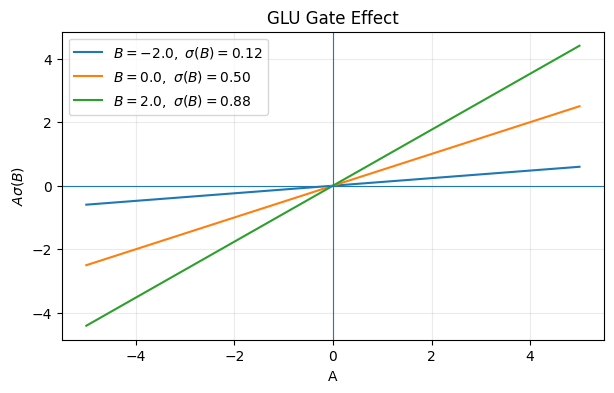

In [136]:
import torch
import matplotlib.pyplot as plt

A = torch.linspace(-5, 5, 1000)

gate_values = [-2.0, 0.0, 2.0]

plt.figure(figsize=(7, 4))

for b in gate_values:
    gate = torch.sigmoid(torch.tensor(b))
    y = A * gate

    plt.plot(
        A.numpy(),
        y.numpy(),
        label=fr"$B={b},\ \sigma(B)={gate.item():.2f}$"
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(alpha=0.25)

plt.xlabel("A")
plt.ylabel(r"$A\sigma(B)$")
plt.title("GLU Gate Effect")
plt.legend()

plt.show()

##Softmax


```
class torch.nn.Softmax(dim=None)

```
Softmax 不是逐元素独立计算的一元函数，而是作用在整个向量上的变换。

假设网络输出：

$$
z=
[z_1,z_2,\cdots,z_C]
$$

Softmax 定义为：

$$
p_i
=
\frac{e^{z_i}}
{\sum_{j=1}^{C}e^{z_j}}
$$

因此所有输出满足：

$$
0<p_i<1
$$

以及：

$$
\sum_{i=1}^{C}p_i=1
$$

所以 Softmax 可以把一组任意实数 logits 转换为一个概率分布。

---

### Softmax 的本质：类别竞争

由于分母包含所有类别：

$$
\sum_j e^{z_j}
$$

因此某一个类别概率升高，会压低其他类别的概率。

所以 Softmax 特别适合：

> **互斥多分类问题**

例如：

- 猫；
- 狗；
- 鸟；

一张图片只能属于其中一个类别。

---

### Softmax 与 Sigmoid 的区别

Sigmoid 对每个输出独立计算：

$$
p_i=\sigma(z_i)
$$

各个类别之间不存在概率和为 1 的约束。

因此 Sigmoid 更适合：

> Multi-label 多标签分类。

Softmax 则满足：

$$
\sum_i p_i=1
$$

因此更适合：

> Multi-class 单标签多分类。

---

### logits

神经网络最后一个线性层通常直接输出：

$$
z_1,z_2,\cdots,z_C
$$

这些值称为：

**logits**

它们不是概率，可以是任意实数。
Softmax把 logits 转换成概率。

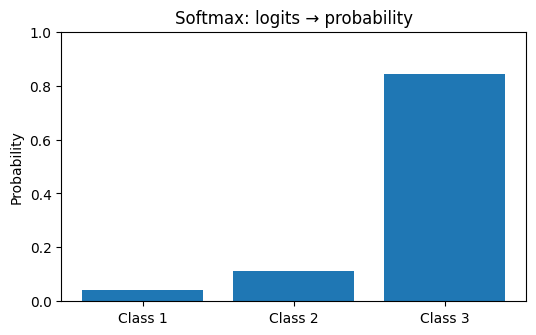

logits: tensor([1., 2., 4.])
probabilities: tensor([0.0420, 0.1142, 0.8438])
sum = tensor(1.0000)


In [140]:

### Code Cell
import torch
import matplotlib.pyplot as plt

logits = torch.tensor([1.0, 2.0, 4.0])

softmax = nn.Softmax(dim=0)
prob = softmax(logits)

plt.figure(figsize=(6, 3.5))
plt.bar(
    ["Class 1", "Class 2", "Class 3"],
    prob.numpy()
)

plt.ylabel("Probability")
plt.title("Softmax: logits → probability")

plt.ylim(0, 1)

plt.show()

print("logits:", logits)
print("probabilities:", prob)
print("sum =", prob.sum())

## Softmin

Softmin 可以直接理解为：

$$
\operatorname{Softmin}(x)
=
\operatorname{Softmax}(-x)
$$

Softmax 会给较大的输入更大的权重，而 Softmin 则会给较小的输入更大的权重。

Softmax 强调最大值，Softmin 强调最小值。

其使用频率明显低于 Softmax。

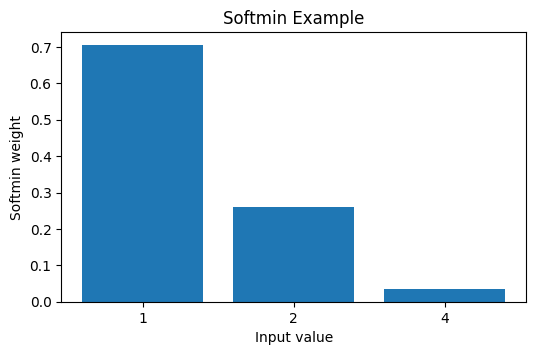

Softmin: tensor([0.7054, 0.2595, 0.0351])


In [137]:
import torch
import matplotlib.pyplot as plt

x = torch.tensor([1.0, 2.0, 4.0])

softmin = nn.Softmin(dim=0)
p = softmin(x)

plt.figure(figsize=(6, 3.5))
plt.bar(["1", "2", "4"], p.numpy())

plt.xlabel("Input value")
plt.ylabel("Softmin weight")
plt.title("Softmin Example")

plt.show()

print("Softmin:", p)

## LogSoftmax

```
class torch.nn.LogSoftmax(dim=None)
```
LogSoftmax 定义为：

$$
\operatorname{LogSoftmax}(z_i)
=
\log
\left(
\frac{e^{z_i}}
{\sum_j e^{z_j}}
\right)
$$

整理可以得到：

$$
\operatorname{LogSoftmax}(z_i)
=
z_i-
\log
\left(
\sum_j e^{z_j}
\right)
$$

表面上看，它似乎只是：

$$
\log(\operatorname{Softmax}(x))
$$

但实际实现中非常重要的一点是：不要简单先计算 Softmax，再计算 log。

原因是数值稳定性。

当某个 Softmax 概率非常接近 0 时：

$$
\log(p)
$$

容易产生严重的浮点数误差。

LogSoftmax 可以通过数学变形直接稳定地计算结果。


Softmax:
tensor([4.0638e-44, 8.1940e-40, 1.0000e+00])

log(Softmax):
tensor([-99.9116, -90.0000,   0.0000])

LogSoftmax:
tensor([-99.9000, -90.0000,   0.0000])


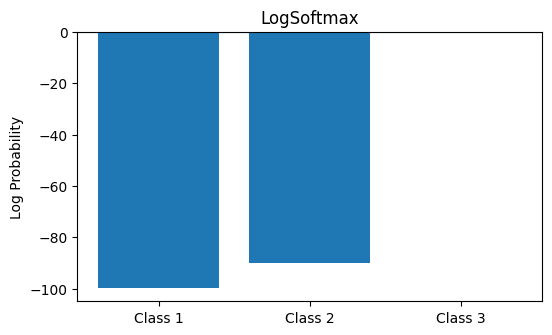

In [143]:
import torch
import matplotlib.pyplot as plt
logits = torch.tensor([0.1, 10.0, 100.0])

softmax = torch.softmax(logits, dim=0)
log_softmax = torch.log_softmax(logits, dim=0)

print("Softmax:")
print(softmax)

print("\nlog(Softmax):")
print(torch.log(softmax))

print("\nLogSoftmax:")
print(log_softmax)

plt.figure(figsize=(6, 3.5))

plt.bar(
    ["Class 1", "Class 2", "Class 3"],
    log_softmax.numpy()
)

plt.ylabel("Log Probability")
plt.title("LogSoftmax")

plt.axhline(0, linewidth=0.8)
plt.show()

## Softmax2d

```
class torch.nn.Softmax2d(*args, **kwargs)

```

Softmax2d 并不是一种新的数学激活函数。

对于 CNN 中典型的输入：

$$
X\in
\mathbb{R}^{N\times C\times H\times W}
$$

Softmax2d 会在每一个空间位置 $(h,w)$ 上，对 $C$ 个 channel 执行 Softmax。

因此：

$$
\sum_{c=1}^{C}
p_{n,c,h,w}=1
$$

典型应用是语义分割。

例如某个像素位置：

- background：0.05
- person：0.85
- car：0.10

三个类别概率之和为 1。

**Softmax2d = 为 CNN 空间特征图准备的按 channel Softmax。**

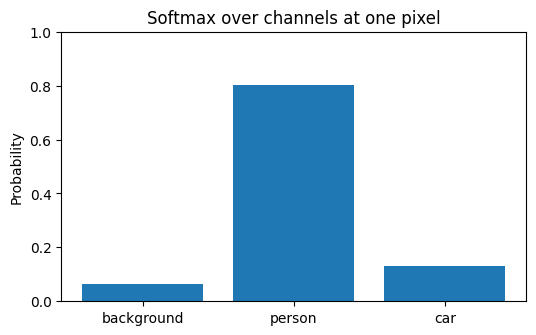

In [144]:
import torch
import matplotlib.pyplot as plt
logits = torch.tensor([0.5, 3.0, 1.2])

prob = torch.softmax(logits, dim=0)

plt.figure(figsize=(6, 3.5))

plt.bar(
    ["background", "person", "car"],
    prob.numpy()
)

plt.ylabel("Probability")
plt.title("Softmax over channels at one pixel")

plt.ylim(0, 1)
plt.show()

## AdaptiveLogSoftmaxWithLoss

`AdaptiveLogSoftmaxWithLoss` 并不是普通的激活函数，而是一个：

$$
\boxed{\text{高效输出层}+\text{Loss}}
$$

的组合结构。

它主要解决：类别数量非常巨大时，普通 Softmax 计算量过大的问题。

---

### 普通 Softmax 的计算问题

假设隐藏层维度为：

$$
d=4096
$$

词表大小为：

$$
V=100000
$$

那么输出层权重矩阵大小为：

$$
4096\times100000
$$

每次都需要计算所有类别的 logits，成本非常高。

这种情况在大词表语言模型中尤其明显。

---

### Adaptive Softmax 的核心思想

不同类别出现频率通常并不均匀。

例如自然语言中：

- 少量高频词出现非常频繁；
- 大量低频词出现概率很低。

因此 Adaptive Softmax 将类别划分为不同区域：

```text
高频类别
    ↓
直接计算

低频类别
    ↓
先判断所属类别组
    ↓
再计算组内类别
```

也就是采用一种分层结构减少平均计算量。高频类别拥有更加直接、精细的计算路径，而低频类别使用更加廉价的分层计算。
```
主要适用于：
- 超大词表语言模型；
- 类别数量非常大的分类问题。
```

In [1]:
# @title
import torch
import torch.nn as nn
import plotly.graph_objects as go

# 输入范围
x = torch.linspace(-6, 6, 1200)

activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(negative_slope=0.1),
    "ELU": nn.ELU(),
    "GELU": nn.GELU(),
    "SiLU / Swish": nn.SiLU(),
    "Mish": nn.Mish(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "Softplus": nn.Softplus(),
}

fig = go.Figure()

for name, activation in activations.items():
    with torch.no_grad():
        y = activation(x)

    # 默认只打开几个最常用的，其他放在图例中等待点击
    default_visible = name in ["ReLU", "GELU", "SiLU / Swish"]

    fig.add_trace(
        go.Scatter(
            x=x.numpy(),
            y=y.numpy(),
            mode="lines",
            name=name,
            visible=True if default_visible else "legendonly"
        )
    )

fig.update_layout(
    title="常用激活函数比较",
    xaxis_title="x",
    yaxis_title="f(x)",
    width=900,
    height=550,
    hovermode="x unified",
)

fig.update_xaxes(
    range=[-6, 6],
    zeroline=True,
    showgrid=True
)

fig.update_yaxes(
    range=[-3, 6],
    zeroline=True,
    showgrid=True
)

fig.show()

 ```
                        Activation
                            │
        ┌───────────────────┼────────────────────┐
        │                   │                    │
   Rectifier系                 Saturating系                Gating系
        │                   │                    │
       ReLU                  Sigmoid                  GLU
        │                   │
 ┌──────┼──────┐           Tanh
 │      │      │
Leaky     ELU     Softplus
 │      │
PReLU     SELU
RReLU     CELU

现代平滑激活：
       ReLU思想
          ↓
    ┌─────┴─────┐
   GELU           SiLU
                │
              HardSwish

轻量化近似：
Sigmoid   → HardSigmoid
Tanh    → Hardtanh
Swish    → HardSwish

概率输出：
Sigmoid
Softmax
LogSoftmax
Softmin

稀疏阈值：
Hardshrink
Softshrink
Threshold
```